# Exploring the momentum/MACD features

Builds the 8-feature panel (`(date, ticker, feature)`) across the 26-ticker ETF universe using `trading_strategies.utils.features`, then looks at distributions, cross-ticker agreement, and time series for a couple of names.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from trading_strategies.utils.features import MACD_PAIRS, MOMENTUM_LOOKBACKS, StreamingFeatureSet

pd.set_option("display.max_columns", None)

## Load raw prices and build the feature panel

In [2]:
raw = pd.read_parquet("../data/raw.parquet")
raw = raw.sort_values(["ticker", "date"]).set_index("date")
raw.groupby("ticker").size().sort_values()

ticker
BND     4708
IGIB    4708
IWM     4708
IYR     4708
IYT     4708
        ... 
FXI     4708
FXY     4708
GDX     4708
HYG     4708
XLY     4708
Length: 61, dtype: int64

In [3]:
def _features_for_one_ticker(group: pd.DataFrame) -> pd.DataFrame:
    feature_set = StreamingFeatureSet(macd_phi=False)
    rows = [feature_set.update(close) for close in group["close"]]
    return pd.DataFrame(rows, index=group.index)


panel = raw.groupby("ticker", group_keys=True).apply(_features_for_one_ticker)
panel.index.names = ["ticker", "date"]
panel = panel.reorder_levels(["date", "ticker"]).sort_index()

print(panel.shape)
panel.tail()

(287188, 8)


mom_1    mom_21    mom_63   mom_126   mom_252  \
date       ticker                                                     
2025-12-31 XLI    -1.017113  0.638526  0.131218  0.498416  1.166151   
           XLP    -0.876628 -0.650551 -0.133858 -0.735369 -0.188953   
           XLU    -0.819275 -1.020937 -0.504131  0.576823  0.944039   
           XLV    -0.664964 -0.080899  1.123342  1.402418  0.798227   
           XLY    -0.746502  0.191986 -0.114740  0.688489  0.230026   

                   macd_8_24  macd_16_48  macd_32_96  
date       ticker                                     
2025-12-31 XLI      0.937754    1.265371    1.229991  
           XLP     -0.285634   -0.030622   -1.036746  
           XLU     -0.820780   -1.095633   -0.013211  
           XLV      0.489977    1.118609    1.602144  
           XLY      0.644255    1.095102    1.400693

## Sanity checks: NaN warm-up period and distribution per feature

The longest lookback (252d momentum) plus the 252d winsorize window means each ticker needs ~500 trading days before every feature is populated.

In [4]:
nan_counts = panel.isna().sum()
first_fully_valid_date = panel.dropna().index.get_level_values("date").min()
print("NaNs per feature:\n", nan_counts)
print("\nFirst fully-valid date across all tickers/features:", first_fully_valid_date)

NaNs per feature:
 mom_1          3660
mom_21         3660
mom_63         3843
mom_126        7686
mom_252       15372
macd_8_24     19093
macd_16_48    19093
macd_32_96    21106
dtype: int64

First fully-valid date across all tickers/features: 2008-08-29 00:00:00


In [5]:
panel.dropna().describe()

,mom_1,mom_21,mom_63,mom_126,mom_252,macd_8_24,macd_16_48,macd_32_96
count,266082.000000,266082.000000,266082.000000,266082.000000,266082.000000,266082.000000,266082.000000,266082.000000
mean,0.008547,0.078663,0.150506,0.202727,0.228949,0.108275,0.209725,0.348719
std,0.971952,0.925222,0.917381,0.948380,1.012325,1.066252,1.211462,1.646472
min,-5.408093,-3.956142,-3.815617,-3.479993,-3.928949,-4.477264,-4.809584,-10.849462
25%,-0.575692,-0.543198,-0.488114,-0.472816,-0.500184,-0.655387,-0.813804,-0.884320
50%,0.045517,0.112584,0.167289,0.192162,0.172162,0.184017,0.332409,0.435439
75%,0.637544,0.725377,0.797228,0.863617,0.899871,0.900358,1.182615,1.424899
max,5.445050,4.036534,4.069235,5.483248,12.663425,4.431357,6.476730,10.369670


## Feature correlation

Are the 5 momentum lookbacks and 3 MACD variants actually adding independent information, or mostly redundant?

,mom_1,mom_21,mom_63,mom_126,mom_252,macd_8_24,macd_16_48,macd_32_96
mom_1,1.000000,0.230013,0.140576,0.104102,0.072009,0.113646,0.051532,0.022951
mom_21,0.230013,1.000000,0.590698,0.435823,0.313120,0.876192,0.738150,0.369774
mom_63,0.140576,0.590698,1.000000,0.693182,0.476051,0.601867,0.799249,0.689728
mom_126,0.104102,0.435823,0.693182,1.000000,0.658025,0.454195,0.672908,0.787307
mom_252,0.072009,0.313120,0.476051,0.658025,1.000000,0.338877,0.526412,0.697302
macd_8_24,0.113646,0.876192,0.601867,0.454195,0.338877,1.000000,0.837561,0.437674
macd_16_48,0.051532,0.738150,0.799249,0.672908,0.526412,0.837561,1.000000,0.777355
macd_32_96,0.022951,0.369774,0.689728,0.787307,0.697302,0.437674,0.777355,1.000000


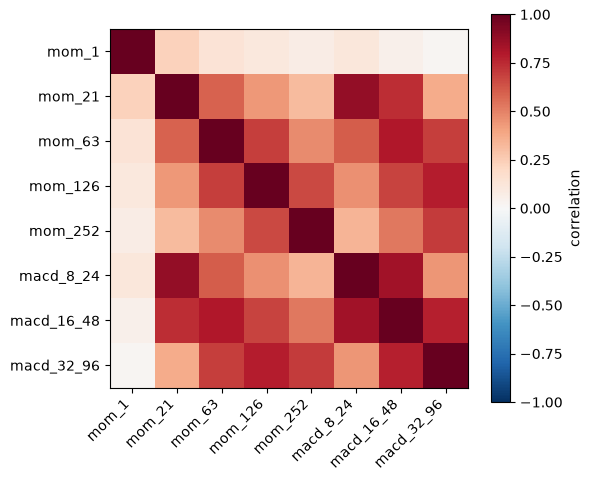

In [6]:
corr = panel.dropna().corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)), corr.columns)
fig.colorbar(im, ax=ax, label="correlation")
fig.tight_layout()
corr

## Time series for one ticker

Pick a ticker and eyeball the feature time series against price, to check the features move sensibly with visible trends.

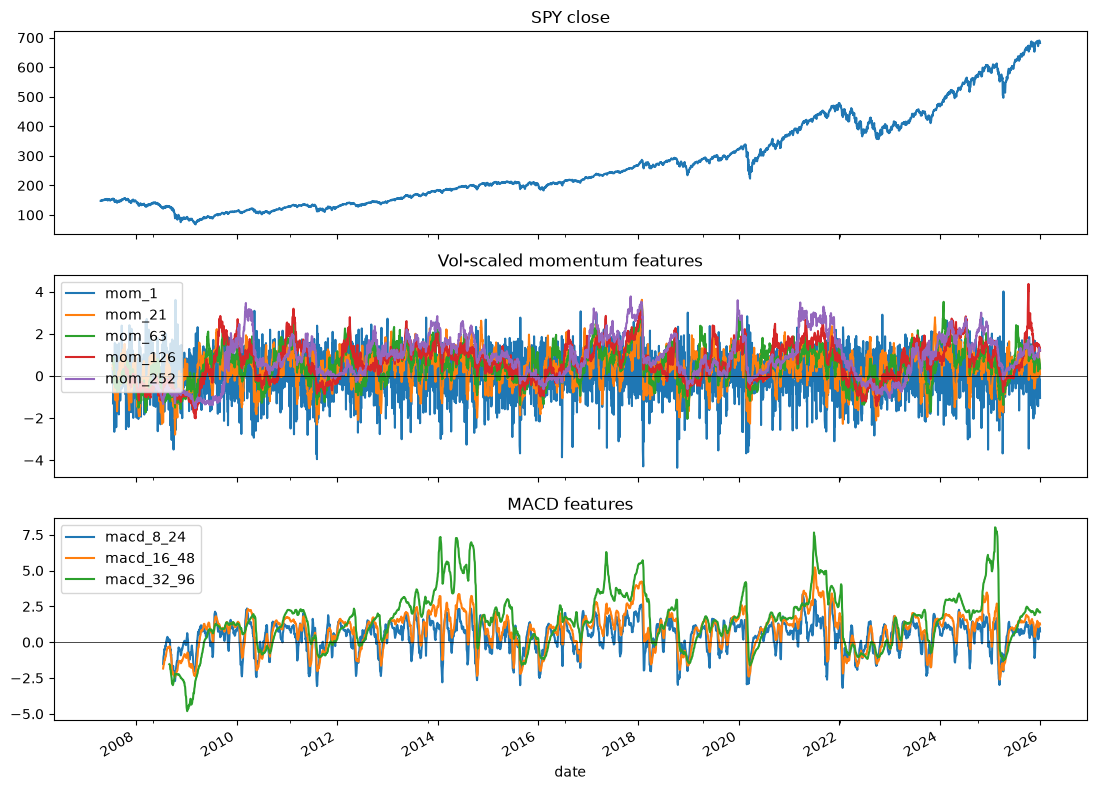

In [7]:
ticker = "SPY"
ticker_features = panel.xs(ticker, level="ticker")
ticker_close = raw.loc[raw["ticker"] == ticker, "close"]

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(ticker_close.index, ticker_close.values)
axes[0].set_title(f"{ticker} close")

mom_cols = [f"mom_{lb}" for lb in MOMENTUM_LOOKBACKS]
ticker_features[mom_cols].plot(ax=axes[1])
axes[1].set_title("Vol-scaled momentum features")
axes[1].axhline(0, color="black", linewidth=0.5)

macd_cols = [f"macd_{short}_{long}" for short, long in MACD_PAIRS]
ticker_features[macd_cols].plot(ax=axes[2])
axes[2].set_title("MACD features")
axes[2].axhline(0, color="black", linewidth=0.5)

fig.tight_layout()

## Winsorize halflife

`winsorize` clips each feature to +/- 5 EWM std around its EWM mean, with
`halflife=31`. This was chosen by a one-off sensitivity sweep (see git
history for this notebook prior to the streaming-features migration):
clipping barely happens at any halflife tested, so the choice doesn't
matter much in practice. Re-running that sweep against the streaming
features would need `_Winsorizer`'s halflife exposed as a per-run
parameter, which isn't needed for the MACD benchmark this repo has --
not done here.